In [1]:
from langchain_core.tools import tool

@tool
def get_stock_price(ticker: str):
    """Retrieve the current stock price for a given company ticker"""
    print(f"Fetching stock price for: {ticker}")
    return "$123.45"


In [2]:
import dotenv

dotenv.load_dotenv()

True

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
model = model.bind_tools([get_stock_price])


In [4]:
def call_llm(state):
    return {"messages": [model.invoke(state["messages"])]}


In [5]:
from langgraph.types import Command, interrupt
from typing_extensions import Literal

def human_review_node(state) -> Command[Literal["call_llm", "run_tool"]]:
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[-1]

    human_review = interrupt({
        "question": "Is this the correct stock ticker?",
        "tool_call": tool_call,
    })

    action = human_review["action"]
    data = human_review.get("data")

    if action == "continue":
        return Command(goto="run_tool")
    elif action == "update":
        updated_message = {
            "role": "ai",
            "content": last_message.content,
            "tool_calls": [{
                "id": tool_call["id"],
                "name": tool_call["name"],
                "args": data,
            }],
            "id": last_message.id,
        }
        return Command(goto="run_tool", update={"messages": [updated_message]})


In [6]:
from langgraph.graph import END

def route_after_llm(state) -> Literal[END, "human_review_node"]:
    if len(state["messages"][-1].tool_calls) == 0:
        return END
    return "human_review_node"


In [7]:
from langgraph.graph import StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

tools = ToolNode(tools=[get_stock_price])

builder = StateGraph(MessagesState)
builder.add_node("call_llm", call_llm)
builder.add_node("run_tool", tools)
builder.add_node("human_review_node", human_review_node)

builder.add_conditional_edges("call_llm", route_after_llm)
builder.add_edge("run_tool", "call_llm")
builder.set_entry_point("call_llm")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)


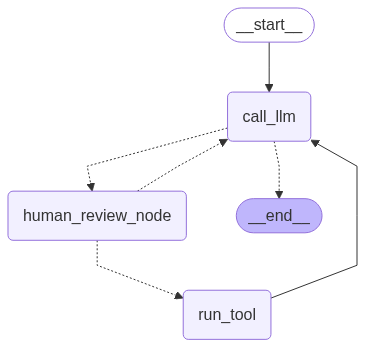

In [8]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [9]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}
initial_input = {"messages": [HumanMessage(content="What is the stock price of Appel?")]}

# First run, may lead to interrupt due to possible misspelling.
graph.invoke(initial_input, config=config, stream_mode="updates")


[{'call_llm': {'messages': [AIMessage(content='I\'m sorry, I cannot find the stock price for "Appel". Did you mean Apple? If not, please provide the correct company name or stock ticker.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--5794bb40-3d70-4aab-90e0-0be3a8e5eca7-0', usage_metadata={'input_tokens': 53, 'output_tokens': 34, 'total_tokens': 322, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 235}})]}}]

In [10]:
# Human confirms or updates the tool call.
from langgraph.types import Command

# If confirmed:
graph.invoke(Command(resume={"action": "continue"}), config=config)

{'messages': [HumanMessage(content='What is the stock price of Appel?', additional_kwargs={}, response_metadata={}, id='8e1c4401-e5c7-496a-b5f7-0124f9e32949'),
  AIMessage(content='I\'m sorry, I cannot find the stock price for "Appel". Did you mean Apple? If not, please provide the correct company name or stock ticker.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--5794bb40-3d70-4aab-90e0-0be3a8e5eca7-0', usage_metadata={'input_tokens': 53, 'output_tokens': 34, 'total_tokens': 322, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 235}})]}

In [11]:
# Or if corrected:
graph.invoke(Command(resume={"action": "update", "data": {"ticker": "AAPL"}}), config=config)

{'messages': [HumanMessage(content='What is the stock price of Appel?', additional_kwargs={}, response_metadata={}, id='8e1c4401-e5c7-496a-b5f7-0124f9e32949'),
  AIMessage(content='I\'m sorry, I cannot find the stock price for "Appel". Did you mean Apple? If not, please provide the correct company name or stock ticker.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--5794bb40-3d70-4aab-90e0-0be3a8e5eca7-0', usage_metadata={'input_tokens': 53, 'output_tokens': 34, 'total_tokens': 322, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 235}})]}

In [17]:


# from langchain_core.messages import HumanMessage
# from langgraph.types import Command

# def handle_user_query_with_review(graph, user_input: str, thread_id: str, user_decision: str, updated_data: dict = None):
#     """
#     Handles a complete human-in-the-loop query interaction.
    
#     Parameters:
#     - graph: Compiled LangGraph object
#     - user_input: The initial user question (e.g., "Stock price of Appel?")
#     - thread_id: Unique ID for the session
#     - user_decision: Either "continue" or "update"
#     - updated_data: Dictionary with corrected tool arguments, if user_decision is "update"
#     """
    
#     config = {"configurable": {"thread_id": thread_id}}
#     initial_input = {"messages": [HumanMessage(content=user_input)]}

#     # First invoke to trigger the LLM and possibly reach an interrupt
#     result = graph.invoke(initial_input, config=config, stream_mode="updates")
#     print(result)
    
#     # Determine how to resume based on user decision
#     if user_decision == "continue":
#         result = graph.invoke(Command(resume={"action": "continue"}), config=config)
#         print(result)
#         return result
    
#     elif user_decision == "update" and updated_data:
#         result = graph.invoke(Command(resume={"action": "update", "data": updated_data}), config=config)
#         print(result)
#         return result
    
#     else:
#         raise ValueError("Invalid user decision or missing updated data for 'update' action.")




In [18]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from langchain_core.messages import HumanMessage
from langgraph.types import Command

# Store conversation state
session_id = "interactive-thread-1"

# Widgets
input_box = widgets.Text(
    value='',
    placeholder='Enter your question...',
    description='Query:',
    layout=widgets.Layout(width='80%')
)

correction_box = widgets.Text(
    value='',
    placeholder='Enter correction (e.g., ticker=AAPL)',
    description='Correction:',
    layout=widgets.Layout(width='80%'),
    disabled=True
)

output_area = widgets.Output()
submit_button = widgets.Button(description="Submit", button_style='primary')
continue_button = widgets.Button(description="Continue")
update_button = widgets.Button(description="Update")
buttons_box = widgets.HBox([continue_button, update_button])

# Hide decision controls initially
buttons_box.layout.display = 'none'
correction_box.layout.display = 'none'

# Save current config
config = {"configurable": {"thread_id": session_id}}

# Callback: Submit initial input
def on_submit_clicked(b):
    output_area.clear_output()
    buttons_box.layout.display = 'none'
    correction_box.layout.display = 'none'
    user_input = input_box.value

    with output_area:
        print(f"User: {user_input}")
        initial_input = {"messages": [HumanMessage(content=user_input)]}
        result = graph.invoke(initial_input, config=config, stream_mode="updates")
        print("System is waiting for your review...")
        buttons_box.layout.display = ''
        correction_box.layout.display = ''

# Callback: Continue without correction
def on_continue_clicked(b):
    buttons_box.layout.display = 'none'
    correction_box.layout.display = 'none'
    with output_area:
        print("Human: Continue")
        result = graph.invoke(Command(resume={"action": "continue"}), config=config)
        print("Graph resumed and completed.")

# Callback: Update tool arguments
def on_update_clicked(b):
    buttons_box.layout.display = 'none'
    correction_box.layout.display = 'none'
    user_input = correction_box.value.strip()
    updated_data = dict(item.split('=') for item in user_input.split(',') if '=' in item)

    with output_area:
        print(f"Human: Update with {updated_data}")
        result = graph.invoke(Command(resume={"action": "update", "data": updated_data}), config=config)
        print("Graph resumed with corrected input.")

# Register callbacks
submit_button.on_click(on_submit_clicked)
continue_button.on_click(on_continue_clicked)
update_button.on_click(on_update_clicked)

# Display interface
display(input_box, submit_button, output_area, correction_box, buttons_box)


Text(value='', description='Query:', layout=Layout(width='80%'), placeholder='Enter your question...')

Button(button_style='primary', description='Submit', style=ButtonStyle())

Output()

Text(value='', description='Correction:', disabled=True, layout=Layout(display='none', width='80%'), placehold…

In [19]:
from typing_extensions import Literal
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from langchain_core.tools import tool
from IPython.display import Image, display


@tool
def weather_search(city: str):
    """Search for the weather in a specific city"""
    print("----")
    print(f"Searching for: {city}")
    print("----")
    return "Sunny!"


# model = ChatOpenAI(model="gpt-4o-mini").bind_tools([weather_search])


def call_llm(state):
    return {"messages": [model.invoke(state["messages"])]}


def human_review_node(state) -> Command[Literal["call_llm", "run_tool"]]:
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[-1]

    human_review = interrupt(
        {
            "question": "Is this correct?",
            "tool_call": tool_call,
        }
    )
    print("Human review values:", human_review)

    review_action = human_review["action"]
    review_data = human_review.get("data")

    if review_action == "continue":
        return Command(goto="run_tool")

    elif review_action == "update":
        updated_message = {
            "role": "ai",
            "content": last_message.content,
            "tool_calls": [
                {
                    "id": tool_call["id"],
                    "name": tool_call["name"],
                    "args": review_data,
                }
            ],
            "id": last_message.id,
        }
        return Command(goto="run_tool", update={"messages": [updated_message]})


def route_after_llm(state) -> Literal[END, "human_review_node"]:
    if len(state["messages"][-1].tool_calls) == 0:
        return END
    else:
        return "human_review_node"


builder = StateGraph(MessagesState)
builder.add_node("call_llm", call_llm)
builder.add_node("run_tool", ToolNode(tools=[weather_search]))
builder.add_node("human_review_node", human_review_node)
builder.add_conditional_edges("call_llm", route_after_llm)
builder.add_edge("run_tool", "call_llm")
builder.set_entry_point("call_llm")

memory = MemorySaver()

graph = builder.compile(checkpointer=memory)


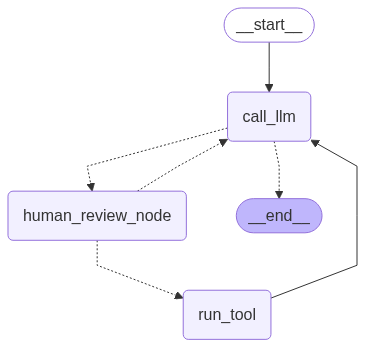

In [20]:
display(Image(graph.get_graph().draw_mermaid_png()))


In [26]:
initial_input = {"messages": [HumanMessage(content="How is the weather in Munic?")]}
config = {"configurable": {"thread_id": "5"}}

first_result = graph.invoke(initial_input, config=config, stream_mode="updates")
first_result


[{'call_llm': {'messages': [AIMessage(content='I cannot tell you the weather in Munich as I do not have access to real-time weather information.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--0a82afd6-e5f0-4ab8-9b1d-2767580ad80d-0', usage_metadata={'input_tokens': 82, 'output_tokens': 21, 'total_tokens': 151, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 48}})]}}]

In [27]:
print(graph.get_state(config).next)


()


In [28]:
graph.invoke(Command(resume={"action": "continue"}), config=config)
config = {"configurable": {"thread_id": "6"}}

graph.invoke(initial_input, config=config, stream_mode="updates")


[{'call_llm': {'messages': [AIMessage(content='I cannot provide you with weather information. My capabilities are limited to providing stock prices.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--fe310902-91d7-4e12-96c4-d91532362622-0', usage_metadata={'input_tokens': 78, 'output_tokens': 17, 'total_tokens': 144, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 49}})]}}]

In [29]:
print(graph.get_state(config).next)


()


In [30]:
graph.invoke(Command(resume={"action": "update", "data": {"city": "Munich"}}), config)

{'messages': [HumanMessage(content='How is the weather in Munic?', additional_kwargs={}, response_metadata={}, id='36037567-60a7-4fa5-aadb-ed447773573e'),
  AIMessage(content='I cannot provide you with weather information. My capabilities are limited to providing stock prices.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--47810f8d-a392-486d-8d95-e8f6e33af8de-0', usage_metadata={'input_tokens': 52, 'output_tokens': 17, 'total_tokens': 133, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 64}}),
  HumanMessage(content='How is the weather in Munic?', additional_kwargs={}, response_metadata={}, id='29b9e556-e07e-4211-a188-63b72d56f094'),
  AIMessage(content='I cannot provide you with weather information. My capabilities are limited to providing stock prices.', additional_kwargs={}, response_metadata={'prompt_fee

In [9]:
# === Core Imports ===
from typing import TypedDict, Optional, Literal
import re

# === LangGraph & LangChain Imports ===
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt

from langchain_core.tools import tool
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel

from langgraph.graph import StateGraph, END, MessagesState

import dotenv

dotenv.load_dotenv()

# === LLM Setup ===
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

# === State Schema ===
class HumanInTheLoopState(TypedDict):
    question: str
    ai_draft: str
    human_feedback: Optional[str]
    final_response: Optional[str]
    moderation_result: Optional[dict]
    rejection_reason: Optional[str]


# === Publish & Reject Tools ===
@tool
def publish_content(content: str):
    """Publishes the final AI content after approval."""
    print("✅ Published:", content)
    return "Published"

@tool
def reject_content(reason: str):
    """Rejects the content and logs the reason."""
    print("❌ Rejected:", reason)
    return f"Rejected: {reason}"


# === LLM Draft Generation ===
def generate_draft_node(state: HumanInTheLoopState):
    question = state["question"]
    prompt = f"""Write a helpful and respectful response to the following question. Avoid any vulgar or offensive language.

Question: {question}
"""
    ai_output = model.invoke(prompt)
    return {"ai_draft": ai_output.content}


# === Moderation Output Schema ===
class ModerationResult(BaseModel):
    status: Literal["clean", "flagged"]
    issues: Optional[list[str]]


# === Parser + Prompt ===
parser = PydanticOutputParser(pydantic_object=ModerationResult)

# Add this near top
FORBIDDEN_KEYWORDS = [
    "kill", "hate", "nazi", "terrorist", "bannedword1", "slur1"
]

# Update prompt
moderation_prompt = PromptTemplate.from_template(
    """You are a content moderation assistant. Analyze the following AI-generated content.

Tasks:
- Detect any vulgar, profane, offensive, or slur-based language.
- Also check if the content contains any of these explicitly forbidden keywords: {forbidden_keywords}
- If any forbidden keyword is present, return status: "flagged", and list them in "issues".
- Respond strictly in the following JSON format:
{{
  "status": "clean" or "flagged",
  "issues": ["list", "of", "detected", "problems"]
}}

Content:
"{content}"
"""
)

# Update moderation node
def ai_moderation_node(state: HumanInTheLoopState):
    draft = state["ai_draft"]
    prompt = moderation_prompt.invoke({
        "content": draft,
        "forbidden_keywords": ", ".join(FORBIDDEN_KEYWORDS),
    })
    response = model.invoke(prompt)
    result = parser.invoke(response)
    return {"moderation_result": result.model_dump()}



# === Human Review Node ===
def human_review_node(state: HumanInTheLoopState) -> Command[Literal["publish", "reject", "moderate"]]:
    draft = state["ai_draft"]
    issues = state["moderation_result"]["issues"]

    review = interrupt({
        "question": f"Content flagged for: {issues}. Approve, update, or reject?",
        "content": draft
    })

    action = review["action"]

    if action == "approve":
        return Command(goto="publish")

    elif action == "update":
        updated = review["updated_content"]
        return Command(goto="moderate", update={"ai_draft": updated, "human_feedback": "Updated by human"})

    elif action == "reject":
        return Command(goto="reject", update={"rejection_reason": review.get("reason", "No reason provided")})


# === Route After Moderation ===
def route_after_moderation(state: HumanInTheLoopState) -> Literal["publish", "human_review_node"]:
    return "publish" if state["moderation_result"]["status"] == "clean" else "human_review_node"


# === Publish Node ===
def publish_node(state: HumanInTheLoopState):
    return {"final_response": publish_content(state["ai_draft"])}


# === Reject Node ===
def reject_node(state: HumanInTheLoopState):
    return {"final_response": reject_content(state["rejection_reason"])}


# === Build the Graph ===
builder = StateGraph(HumanInTheLoopState)

builder.add_node("generate_draft", generate_draft_node)
builder.add_node("moderate", ai_moderation_node)
builder.add_node("publish", publish_node)
builder.add_node("reject", reject_node)
builder.add_node("human_review_node", human_review_node)

builder.add_edge("generate_draft", "moderate")
builder.add_conditional_edges("moderate", route_after_moderation)
builder.add_edge("human_review_node", "moderate")
builder.add_edge("reject", END)
builder.add_edge("publish", END)

builder.set_entry_point("generate_draft")

graph = builder.compile(checkpointer=MemorySaver())


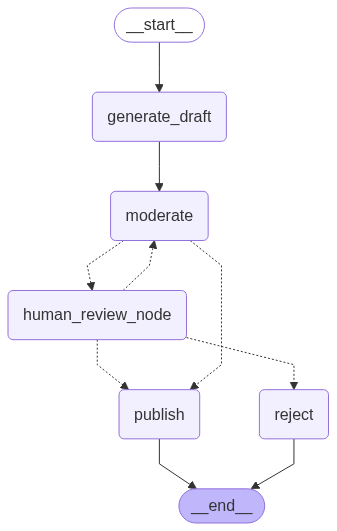

In [10]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

# Scenario A: Human Rejects the Draft

In [3]:
initial_input = {
    "question": "Why do some people still support nazi ideologies?",
    "ai_draft": "",
    "human_feedback": None,
    "final_response": None,
    "moderation_result": None,
    "rejection_reason": None,
}
config = {"configurable": {"thread_id": "test-reject"}}

graph.invoke(initial_input, config=config, stream_mode="updates")


[{'generate_draft': {'ai_draft': "It's a disturbing and complex question, and it's important to approach it with a clear understanding that Nazi ideology is universally condemned for its horrific crimes and hateful nature.\n\nWhile the vast majority of people abhor Nazi ideology, some individuals still express support due to a combination of factors, which often include:\n\n1.  **Feelings of Disenfranchisement or Grievance:** Some individuals may feel economically insecure, socially marginalized, or that their way of life is threatened by societal changes. Nazi ideology, like other extremist movements, can exploit these feelings by offering simplistic answers and scapegoats for complex problems.\n\n2.  **Scapegoating and Blame:** Nazi ideology thrives on blaming specific groups (e.g., Jewish people, Roma, LGBTQ+ individuals, immigrants) for societal problems, economic hardship, or perceived declines. For those looking for easy answers or unwilling to confront complex realities, this na

In [4]:
print(graph.get_state(config).next)

('human_review_node',)


In [5]:
graph.invoke(
    Command(resume={
        "action": "reject",
        "reason": "Too academic and indirectly justifies dangerous ideologies."
    }),
    config=config
)


❌ Rejected: Too academic and indirectly justifies dangerous ideologies.


/var/folders/c9/h7x3gp7x57n7kz8n91yjhw6w0000gn/T/ipykernel_14932/996989244.py:140: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  return {"final_response": reject_content(state["rejection_reason"])}


{'question': 'Why do some people still support nazi ideologies?',
 'ai_draft': "It's a disturbing and complex question, and it's important to approach it with a clear understanding that Nazi ideology is universally condemned for its horrific crimes and hateful nature.\n\nWhile the vast majority of people abhor Nazi ideology, some individuals still express support due to a combination of factors, which often include:\n\n1.  **Feelings of Disenfranchisement or Grievance:** Some individuals may feel economically insecure, socially marginalized, or that their way of life is threatened by societal changes. Nazi ideology, like other extremist movements, can exploit these feelings by offering simplistic answers and scapegoats for complex problems.\n\n2.  **Scapegoating and Blame:** Nazi ideology thrives on blaming specific groups (e.g., Jewish people, Roma, LGBTQ+ individuals, immigrants) for societal problems, economic hardship, or perceived declines. For those looking for easy answers or un

In [6]:
print(graph.get_state(config).next)

('human_review_node',)


In [7]:
graph.invoke(
    Command(resume={
        "action": "reject",
        "reason": "close it"
    }),
    config=config
)

❌ Rejected: close it


{'question': 'Why do some people still support nazi ideologies?',
 'ai_draft': "It's a disturbing and complex question, and it's important to approach it with a clear understanding that Nazi ideology is universally condemned for its horrific crimes and hateful nature.\n\nWhile the vast majority of people abhor Nazi ideology, some individuals still express support due to a combination of factors, which often include:\n\n1.  **Feelings of Disenfranchisement or Grievance:** Some individuals may feel economically insecure, socially marginalized, or that their way of life is threatened by societal changes. Nazi ideology, like other extremist movements, can exploit these feelings by offering simplistic answers and scapegoats for complex problems.\n\n2.  **Scapegoating and Blame:** Nazi ideology thrives on blaming specific groups (e.g., Jewish people, Roma, LGBTQ+ individuals, immigrants) for societal problems, economic hardship, or perceived declines. For those looking for easy answers or un

In [8]:
graph.invoke(
    Command(resume={
        "action": "update",
        "updated_content": (
            "These people spread hate online, recruiting vulnerable individuals into dangerous groups."
        )
    }),
    config=config
)

{'question': 'Why do some people still support nazi ideologies?',
 'ai_draft': 'These people spread hate online, recruiting vulnerable individuals into dangerous groups.',
 'human_feedback': 'Updated by human',
 'final_response': 'Rejected: close it',
 'moderation_result': {'status': 'flagged', 'issues': ['hate']},
 'rejection_reason': 'close it',
 '__interrupt__': [Interrupt(value={'question': "Content flagged for: ['hate']. Approve, update, or reject?", 'content': 'These people spread hate online, recruiting vulnerable individuals into dangerous groups.'}, resumable=True, ns=['human_review_node:a3c819c2-0f36-880b-f780-ca6117202b32'])]}

In [ ]:
graph.invoke(
    Command(resume={
        "action": "update",
        "updated_content": (
            "These people spread hate online, recruiting vulnerable individuals into dangerous groups."
        )
    }),
    config=config
)